# Overview

Notebook for documenting the processing of the raw GBIF occurrence data in order to get a data frame of relevant image URLs and metadata. 

While filtering for images of insects on flowers specifically was not possible, efforts were made to remove images from collections, laboratory settings, fossils, and other irrelevant sources.

Also, taxonomic and geographical filters were applied to refine the data.

For the meaning of the variables in the files occurrence.txt and multimedia.txt, see also the links provided in the file `meta.xml` that comes with the raw GBIF data download.

I have doubts about the strictness of the criteria for flower backgrounds. I guess that on average, only about a third of the images are likely to be on flowers, and for some rare species, images on flowers might not be available. Adopting strict criteria for flower backgrounds could result in a highly imbalanced dataset, where rare species are even further disadvantaged.

# Global settings

Set the imported libraries & packages, any relative paths.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import sys
import os
import git
import random

from PIL import Image
from IPython.display import HTML

# Import needed functions from the data_processing_utils.py file.
from data_processing_utils import (
    get_column_names, display_images, count_lines_in_file, 
    read_random_sample, count_missing_vals
    )

Set the relative path(s)

In [4]:
# Find the working directory of the parent repository.
# This will be used to build various data paths.
repo = git.Repo('.', search_parent_directories=True)
parent_dir = repo.working_tree_dir
print(parent_dir)

/home/vs66tavy/iDiv Dropbox/Valentin Stefan/insect-detection/pai_p3_diptera_families/PAI_diptera


# Read & process occurrence & multimedia data

## GBIF's API (interactive web page)

I used the GBIF's API via their interactive web page. I searched for “Diptera” at https://www.gbif.org/occurrence/search

When asked: “Your search matches a Order: 'Diptera'. Do you wish to limit your search to this taxon only?” select “YES”

<figure>
<img src="./notebook_img/diptera_taxat_yes_no.jpg" width="200"/>
<figcaption>Limit the search on Diptera</figcaption>
</figure>

Then apply these filters:
- Occurrence status: Present
- Media type: Image

<figure>
<img src="./notebook_img/diptera_api_filters.jpg" width="300"/>
<figcaption>Apply these filters</figcaption>
</figure>

Then I clicked on the DOWNLOAD tab and selected the option "DARWIN CORE ARCHIVE". The request will be processed by the GBIF servers and it might time some time until the occurrence metadata is ready for download.

<figure>
<img src="./notebook_img/gbif_download_tab.jpg" width="400"/>
<figcaption>The DOWNLOAD tab</figcaption>
</figure>


GBIF occurrence data citation:

> GBIF.org (01 February 2023) GBIF Occurrence Download https://doi.org/10.15468/dl.xv6g47 

## Notes

I stored the unzip-ed data on my local the Downloads folder so to avoid overloading Dropbox
`~/Downloads/pai_p3_diptera_families/0268791-220831081235567/`

The entire unzip-ed data folder `0268791-220831081235567` is 5.9 GB, with `occurrence.txt` 3.1 GB and `multimedia.txt` 794 MB. The two txt files are tab delimited and are the files used further.

GBIF informs that there should be "2,397,900 occurrences included in download", which means that the file `occurrence.txt` should have that many data rows.
However, I am not sure why some rows are not parsed correctly. So, when reading the txt files below, to avoid errors like this:
> ParserError: Error tokenizing data. C error: Expected 8 fields in line 51, saw 14

I used `on_bad_lines='skip'`.

You will lose a few dozen rows, but that it is a small drop in the ocean.

To cope with the warning that some columns 
> `have mixed types. Specify the dtype option on import or set low_memory=False.`

I used `dtype=str` below in `pd.read_csv()`

I also thought that it's safer to read the data as strings to avoid unexpected data type conversions during the reading process. This should ensure data type consistency cross the two txt files as well, especially important when merging on a common key.

The encoding of the data files seems to be "UTF-8" as suggested by the output of the Linux commands:
```bash
file -bi occurrence.txt
file -bi multimedia.txt
```
This is also confirmed by the `encoding="UTF-8"` pointed out in the meta.xml file that comes with the dataset.

Note that the file `occurrence.txt` has too many columns and can be confusing to understand all this occurrence metadata.

From previous projects, I learned that only some of the columns used below can carry useful info for us (some of them are optional or some turned out to not carry useful info for the filters).

From the total of 259 variables, I only read these ones so that I do not run out of RAM.
```python
'gbifID', 'order', 'family', 'genus', 'specificEpithet', 'species', 
'lifeStage', 'sex', 'continent', 'countryCode', 'level0Name', 'level0Gid',
'publisher', 'collectionID', 'datasetName', 'basisOfRecord', 'year', 
'samplingProtocol', 'identifiedBy', 'nomenclaturalStatus', 'repatriated'
```

For location filtering, only the `continent` and `countryCode` columns were utilized due to fewer missing values compared to `level0Name` and `level0Gid`. See the section "Location filters" at the end of this notebook.

I also didn't end up using these variables: `sex`, `order` (order is known here and it's Diptera for the entire dataset).

In [5]:
# Path to the occurrence.txt file.
occ_txt_path = "/home/vs66tavy/Downloads/pai_p3_diptera_families/0268791-220831081235567/occurrence.txt"

occ_column_names = get_column_names(occ_txt_path)
print(f"Number of columns in occurrence.txt: {len(occ_column_names)}")

Number of columns in occurrence.txt: 259


Below I took a sample of just 1000 records, but all columns from occurrence.txt.
I used this to visually inspect the dataset and get a general feeling of it.

In [6]:
df_occ_raw_sample = read_random_sample(occ_txt_path, 1000)
df_occ_raw_sample.shape

(1000, 259)

In [7]:
# Save the sampled data frame to a file
file_rel_path = 'data/gbif_occurences/raw/occurrence_sampled_1000_rows_all_cols.txt'
file_path = os.path.join(parent_dir, file_rel_path)
df_occ_raw_sample.to_csv(file_path, sep='\t', index=False, header=True, encoding='UTF-8')

## Read occurrence.txt & multimedia.txt files

In [8]:
# Read the occurrence.txt table
# list of specific columns to be read from the file
cols = ['gbifID', 'order', 'family', 'genus', 'specificEpithet', 'species', 
        'lifeStage', 'sex', 'continent', 'countryCode', 'level0Name', 'level0Gid',
        'publisher', 'collectionID', 'datasetName', 'basisOfRecord', 'year', 
        'samplingProtocol', 'identifiedBy', 'nomenclaturalStatus', 'repatriated']
        
df_occ_subset = pd.read_csv(occ_txt_path, usecols=cols, sep='\t', dtype=str, 
                        on_bad_lines='skip', encoding="UTF-8")

In [9]:
# Number of rows and columns in the selected occurrence data frame
df_occ_subset.shape

(2397832, 21)

In [10]:
size = sys.getsizeof(df_occ_subset) / float(1024**3)
print( "Size of data frame df_occ_subset: {:.2f} GB".format(size) )

Size of data frame df_occ_subset: 2.64 GB


In [11]:
# Read the multimedia.txt table
media_txt_path = "/home/vs66tavy/Downloads/pai_p3_diptera_families/0268791-220831081235567/multimedia.txt"

df_media_raw = pd.read_csv(media_txt_path, sep='\t', dtype=str, 
                            on_bad_lines='skip', encoding="UTF-8")
                            
df_media_raw['media_id'] = range(1, len(df_media_raw) + 1)

In [12]:
# Number of rows and columns in the multimedia data frame
df_media_raw.shape

(3448713, 16)

In [13]:
df_media_raw.columns

Index(['gbifID', 'type', 'format', 'identifier', 'references', 'title',
       'description', 'source', 'audience', 'created', 'creator',
       'contributor', 'publisher', 'license', 'rightsHolder', 'media_id'],
      dtype='object')

In [14]:
size = sys.getsizeof(df_media_raw) / float(1024**3)
print( "Size of data frame df_media_raw: {:.2f} GB".format(size) )

Size of data frame df_media_raw: 2.90 GB


The variable `gbifID` is a unique key in `occurrence.txt` but not in `multimedia.txt`. 
Note also that the variable `identifier` is not a unique key in multimedia.txt.
That is why I created `media_id` above, so that there is a unique key there as well.

In [15]:
# Check if gbifID is unique in df_occ_subset
test1 = df_occ_subset['gbifID'].duplicated().any() # False = no duplicates

# Check if gbifID is unique in df_media_raw
test2 = df_media_raw['gbifID'].duplicated().any() # True = there are duplicates

# Check if identifier is unique in df_media_raw
test3 = df_media_raw['identifier'].duplicated().any() # True = there are duplicates

print(test1, test2, test3)

False True True


# Filter data

Filter the dataset using a series of criteria. The objective is to select the target pollinators and prioritize images that are most likely to depict insects on flowers.

## Filter for target taxa.

Read the 16 families of Diptera that are known to have pollinator species and are considered as target taxa here.

In [16]:
# Read target taxa
path = "/home/vs66tavy/Dropbox (iDiv)/insect-detection/taxonomy/tk-lists-notes/Diptera.xlsx"
target_taxa_raw = pd.read_excel(path, sheet_name=0)
# Select only the columns that are needed.
target_taxa = target_taxa_raw[['superfamily', 'family']].copy()

In [17]:
# Double check if target taxa exists in the occurrence data
# There might be typos and we do not want to miss any taxa due to that.
families_in_occ = df_occ_subset['family'].unique()
taxa_isin = target_taxa['family'].isin(families_in_occ)
target_taxa['exists_in_occ'] = taxa_isin

if all(taxa_isin):
    print("All target families are present in the occurrence data.")
else:
    print("PROBLEM! Some target families are not present in the occurrence data.")
    print( target_taxa[target_taxa['exists_in_occ'] == False] )

All target families are present in the occurrence data.


In [18]:
# Select only the target families as defined by TK
mask = df_occ_subset['family'].isin(target_taxa['family'])
df_occ = df_occ_subset[mask]

## Discard unwanted life stages.

See also http://rs.tdwg.org/dwc/terms/lifeStage

In [19]:
# Stats on the life stages
df_occ['lifeStage'].value_counts(dropna=False).sort_values(ascending=False)

NaN         438433
Imago       428772
Adult       106001
Unknown      84678
Larva         2414
Nymph          558
Pupa           445
Egg            372
Immature        96
Juvenile        17
Name: lifeStage, dtype: int64

In [20]:
# Keep: NaN, Imago, Adult, Unknown
mask = df_occ['lifeStage'].isin([np.nan, "Imago", "Adult", "Unknown"])
df_occ = df_occ[mask]

## Discard any unidentified genera and species

http://rs.tdwg.org/dwc/terms/genus

http://rs.tdwg.org/dwc/terms/specificEpithet

In [21]:
# Double check if there are any NaN values in the genus column.
print( df_occ['genus'].isna().sum() )
# df_occ['genus'].isnull().sum() # gives same results as above

# Remove rows with NaN values in the genus column.
df_occ.dropna(subset=['genus'], inplace=True)

29408


In [22]:
# Do the same for the column specificEpithet
print( df_occ['specificEpithet'].isna().sum() )
df_occ.dropna(subset=['specificEpithet'], inplace=True)

99263


## Merge occurrence with multimedia data

At this point we can merge the selected occurrence records with the raw multimedia data so that we apply further filters.

Note that for each `gbifID` in the occurrence table there can be more entries in the media table. So, `gbifID` is unique only in the occurrence table. The join will be one-to-many and take all available rows from the media table that correspond to a given `gbifID` from the occurrence table.

In [23]:
df_occmed = df_occ.merge(df_media_raw, on='gbifID')

In [24]:
# Number of rows and columns in the merged data frame
df_occmed.shape

(1447149, 36)

In [25]:
df_occmed.columns

Index(['gbifID', 'publisher_x', 'collectionID', 'datasetName', 'basisOfRecord',
       'sex', 'lifeStage', 'year', 'samplingProtocol', 'continent',
       'countryCode', 'identifiedBy', 'order', 'family', 'genus',
       'specificEpithet', 'nomenclaturalStatus', 'species', 'repatriated',
       'level0Gid', 'level0Name', 'type', 'format', 'identifier', 'references',
       'title', 'description', 'source', 'audience', 'created', 'creator',
       'contributor', 'publisher_y', 'license', 'rightsHolder', 'media_id'],
      dtype='object')

In [26]:
# Release memory by deleting the data frames that are no longer needed
del df_occ_raw_sample
del df_occ_subset
del df_media_raw
del df_occ

Check the values in `basisOfRecord` variable.

Remove anything that indicates a non-natural background in the images.

See also http://rs.tdwg.org/dwc/terms/basisOfRecord

In [27]:
df_occmed['basisOfRecord'].value_counts(dropna=False).sort_values(ascending=False)

HUMAN_OBSERVATION      1392209
PRESERVED_SPECIMEN       52257
MATERIAL_SAMPLE           1128
MACHINE_OBSERVATION        794
FOSSIL_SPECIMEN            716
OCCURRENCE                  44
OBSERVATION                  1
Name: basisOfRecord, dtype: int64

In [28]:
keep_values = ['HUMAN_OBSERVATION', 'PRESERVED_SPECIMEN', 'MATERIAL_SAMPLE',
                'MACHINE_OBSERVATION', 'OCCURRENCE', 'OBSERVATION']
mask = df_occmed['basisOfRecord'].isin(keep_values)
df_occmed = df_occmed[mask]

Check values in `type` variable.

See also http://purl.org/dc/terms/type

In [29]:
df_occmed['type'].value_counts(dropna=False).sort_values(ascending=False)

StillImage    1446109
NaN               305
Sound              19
Name: type, dtype: int64

In [30]:
keep_values = ['StillImage', np.nan]
mask = df_occmed['type'].isin(keep_values)
df_occmed = df_occmed[mask]

Check values in the `format` variable.

http://purl.org/dc/terms/format

In [31]:
df_occmed['format'].value_counts(dropna=False).sort_values(ascending=False)

image/jpeg           1432833
NaN                     5057
image/png               4245
jpeg                    2978
image/tiff              1156
image/gif                 64
image/pjpeg               30
image/scan                23
image/x-canon-cr2         16
image/tif                  7
image/bmp                  5
Name: format, dtype: int64

In [32]:
keep_values = ['image/jpeg', np.nan, 'image/png', 'jpeg', 'image/tiff']
mask = df_occmed['format'].isin(keep_values)
df_occmed = df_occmed[mask]

Check values in the `samplingProtocol` variable.

See also http://rs.tdwg.org/dwc/terms/samplingProtocol

In [33]:
spl_prot = df_occmed['samplingProtocol'].value_counts(dropna=False).sort_values(ascending=False)
print(spl_prot.shape)
spl_prot

(337,)


NaN                             1239674
seen                             167649
observed                          19836
caught by hand and released        5240
caught by hand and collected       2019
                                 ...   
Trap 767, Propyl glycol               1
Trap 833 (Biolure)                    1
Trap 302 (Dead Flies)                 1
Trap 191 (Prop Glycol)                1
by netting                            1
Name: samplingProtocol, Length: 337, dtype: int64

In [34]:
# I decided to keep them all and we will do a visual inspection later.

# Keep the NaNs, seen & observed. All the others most probably do not contain
# images with insects on flowers.
# keep_values = [np.nan, 'seen', 'observed']
# mask = df_occmed['samplingProtocol'].isin(keep_values)
# df_occmed = df_occmed[mask]

Check values in the `repatriated` variable. 

Initially I suspected that these might not be at all images of insects on flowers, but some are, so I kept all values.

See also http://rs.gbif.org/terms/1.0/repatriated

In [35]:
df_occmed['repatriated'].value_counts(dropna=False).sort_values(ascending=False)

false    1065034
true      370675
NaN        10560
Name: repatriated, dtype: int64

In [36]:
mask = df_occmed['repatriated'] == "true"
cols_kept = ['genus', 'specificEpithet', 'identifier']
df_temp = df_occmed.loc[mask, cols_kept].head(10)

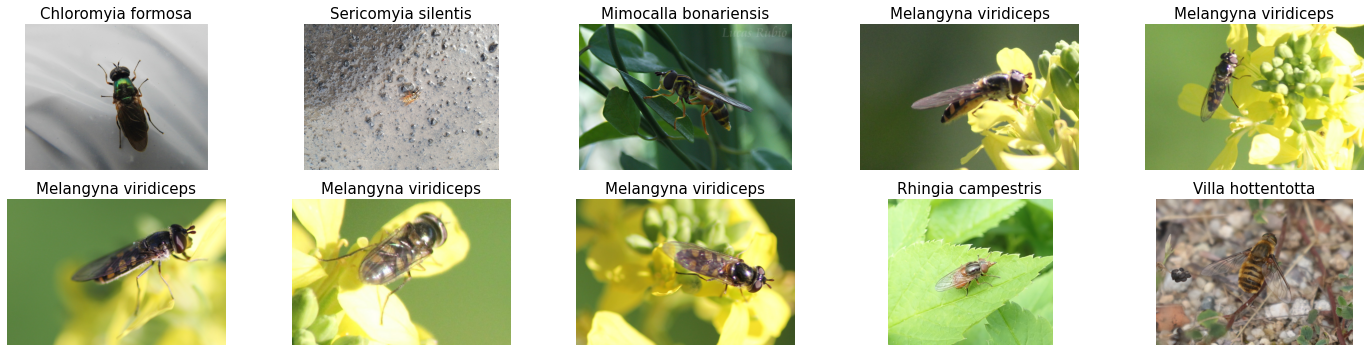

In [37]:
# Some of the occurrences marked as repatriated can be insects on flowers.
display_images(df_temp, 'identifier', plot_nrows=2, plot_ncols=5, figsize=(20, 5), fontsize=15)

Check values in the `datasetName` & `publisher` variables.

`publisher_x` comes from the occurrence.txt file and `publisher_y` from the multimedia.txt file and were renamed to _x and _y during the merging process above and both were kept.

However this doesn't help with filtering for insects on flowers.

See also:
- http://rs.tdwg.org/dwc/terms/datasetName
- publisher_x & publisher_y - http://purl.org/dc/terms/publisher

In [38]:
df_occmed['datasetName'].value_counts(dropna=False).sort_values(ascending=False)

iNaturalist research-grade observations                              719166
NaN                                                                  641078
Artportalen                                                           58677
BugGuide                                                              17118
Kartleggingsmidler Sabima                                              3952
                                                                      ...  
Miljodir_naturtypekartlegging_2022                                        1
iNaturalist observations                                                  1
Kartleggingsmidler Sabima, Bioblitz i Porsanger 2021                      1
Kartlegging av rødlistearter - Sabima , Kartleggingsmidler Sabima         1
Hagearter                                                                 1
Name: datasetName, Length: 83, dtype: int64

In [39]:
# publisher_x is from the occurrence.txt file
df_occmed['publisher_x'].value_counts(dropna=False).sort_values(ascending=False)

iNaturalist.org                                                                                         719167
Observation.org                                                                                         544948
SLU Artdatabanken                                                                                        58677
The Norwegian Biodiversity Information Centre (NBIC)                                                     44031
United States Geological Survey                                                                          17118
MNHN - Museum national d'Histoire naturelle                                                              13920
Museum of Comparative Zoology, Harvard University                                                         9584
Natural History Museum                                                                                    5535
University of Hawaii                                                                                      4717
N

In [40]:
# publisher_x is from the multimedia.txt file
df_occmed['publisher_y'].value_counts(dropna=False).sort_values(ascending=False)

iNaturalist                                          719167
NaN                                                  715290
Museum of Comparative Zoology, Harvard University      4795
Smithsonian Institution, NMNH, Entomology              3390
Field Museum of Natural History                        2947
PlutoF                                                  679
Museu de Ciències Naturals de Barcelona                   1
Name: publisher_y, dtype: int64

Check values in the `year` variable.

Be aware that if there are any NaNs, they can be valid images with possible insect on flowers, so do not discard them. I learned this from working on Paper 1.
The bing chunk of the images are recent. I decided not to discard anything here.

See also http://rs.tdwg.org/dwc/terms/year

In [41]:
df_occmed['year'].value_counts(dropna=False).sort_values(ascending=False)

2022    360597
2021    355103
2020    247186
2019    138213
2018     71406
         ...  
1886         2
1890         2
1860         1
1880         1
1875         1
Name: year, Length: 179, dtype: int64

Check values in the `identifier` variable.

This variable contains the URLs to the images as provided by the organizations that upload their occurrence metadata to GBIF. These are the URLs from which we can sample and then download images that will be manually curated and annotated and then used for training, validation and test.

See also http://purl.org/dc/terms/identifier


No NaN values are present in the URL (identifier) column. 

However, there are a few duplicates. These duplicates occur when multiple insects are present in a single image and each is identified separately, resulting in the same image being referred to multiple times. However, it's not possible to determine which insect is which without manual inspection by a taxonomist, which would be a time-consuming task with limited benefit, as there are only few such cases. Therefore, I decided to drop these few duplicated cases.

In [42]:
# Check if there are any NaN values
print( df_occmed['identifier'].isna().sum() )
print( df_occmed['identifier'].isnull().sum() )

320
320


In [43]:
# Remove rows with NaN values in the 'identifier' column
df_occmed = df_occmed.dropna(subset=['identifier'])

In [44]:
# Check if identifier is unique. Are there duplicates?
df_occmed['identifier'].duplicated().any() # Expect False

True

In [45]:
# Check the duplicates
# keep=False: marks all duplicates as True (not just the first occurrence)
mask = df_occmed['identifier'].duplicated(keep=False)
df_temp = df_occmed.loc[mask, cols_kept]
df_temp.shape

(166, 3)

In [46]:
# For example, the following two rows are duplicates of the same URL
idx_example = [123, 137]
df_temp.iloc[idx_example]

,genus,specificEpithet,identifier
831606,Eristalis,tenax,https://inaturalist-open-data.s3.amazonaws.com...
948674,Mesembrina,meridiana,https://inaturalist-open-data.s3.amazonaws.com...


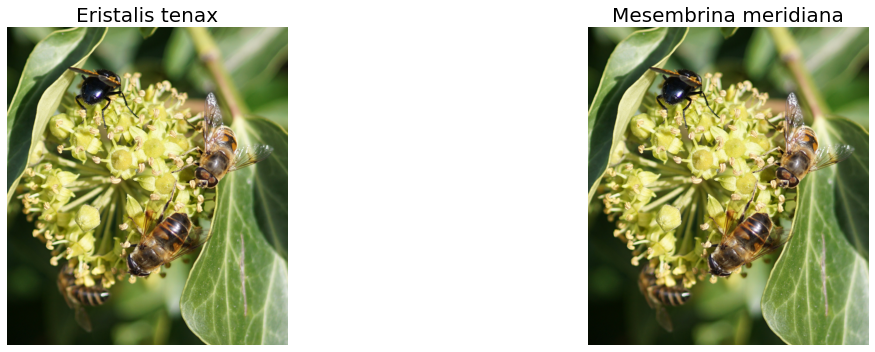

In [47]:
display_images(df_temp.iloc[idx_example], 'identifier', 
                plot_nrows=1, plot_ncols=2, figsize=(20, 5), fontsize=20)

In [48]:
# Drop all duplicates
n_rows_before = df_occmed.shape[0]
df_occmed = df_occmed.drop_duplicates(subset='identifier', keep=False)
n_rows_after = df_occmed.shape[0]
print(f"Number of rows dropped: {n_rows_before - n_rows_after}")

Number of rows dropped: 166


## Check values in nomenclaturalStatus

This column is not very informative unfortunately. Most of data is missing and some are "valid". I didn't apply any filter.

See details about this variable at http://rs.tdwg.org/dwc/terms/nomenclaturalStatus

In [49]:
df_occmed['nomenclaturalStatus'].value_counts(dropna=False).sort_values(ascending=False)

NaN      1387115
valid      58668
Name: nomenclaturalStatus, dtype: int64

# Location filters

Some records (occurrences) lack continent information. However, country information is available for some of these records, which can be used to determine the continent. Our goal is to only retain species encountered in Europe. A direct filter based on continent information could result in the loss of species that are present in multiple continents. Therefore, it is useful to identify species found both in Europe and other continents, and keep those records as well.

While it is possible that the flower background in other continents might not be relevant for Europe, it is important to note that plant species can span across continents. The dataset does not account for this, however, I do not see it as a major concern. I am more focused on having as many images as possible for as many species of insects as possible so that we have a diverse pool to sample from.

In [50]:
df_occmed['continent'].value_counts(dropna=False).sort_values(ascending=False)

EUROPE           916833
NORTH_AMERICA    407525
OCEANIA           44794
NaN               30788
ASIA              17470
SOUTH_AMERICA     17279
AFRICA            11094
Name: continent, dtype: int64

For those records without continent, determine if they are in Europe based on their available country codes.

In [51]:
# Read country ISO code data from GitHub - ISO-3166-Countries-with-Regional-Codes
# See https://github.com/lukes/ISO-3166-Countries-with-Regional-Codes
country_url = 'https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv'
country = pd.read_csv(country_url)

# Get the ISO-2 codes of the countries in Europe.
# Based on them, we can filter the occurrences in Europe.
mask = country['region'].isin(["Europe"])
eu_iso_codes = country.loc[mask, 'alpha-2']

In the occurrence dataset, the `countryCode` variable seems to be more comprehensive than `level0Gid` and `level0Name` because it has less NaN values. Therefore, we can use `countryCode` to try to squeeze any further continent info.

In [52]:
print(count_missing_vals(df_occmed, 'continent', 'countryCode'))
print(count_missing_vals(df_occmed, 'continent', 'level0Gid'))
print(count_missing_vals(df_occmed, 'continent', 'level0Name'))

Number of records without continent and no countryCode: 9185
Number of records without continent and no level0Gid: 30530
Number of records without continent and no level0Name: 30530


In [53]:
# Based on the country codes, we can update the occurrences in Europe.
mask = df_occmed['countryCode'].isin(eu_iso_codes)
df_occmed.loc[mask, 'continent'] = 'EUROPE'

In [54]:
# We gained a few more records with continent information.
df_occmed['continent'].value_counts(dropna=False).sort_values(ascending=False)

EUROPE           923596
NORTH_AMERICA    407525
OCEANIA           44794
NaN               29813
SOUTH_AMERICA     17279
ASIA              14563
AFRICA             8213
Name: continent, dtype: int64

Include the non-European occurrences of European species.

In [55]:
# Combine the genus and specificEpithet columns into one column
df_occmed['genus_epithet'] = df_occmed['genus'] + "_" + df_occmed['specificEpithet']

In [56]:
# Group the data by "genus_epithet", then checks if the value "EUROPE" is in 
# the values of the "continent" column for each group. If "EUROPE" is in the 
# values of the "continent" column for a group, it will return True. 
# Otherwise, it will return False.
df_gr = df_occmed.groupby('genus_epithet')['continent']
df_occmed['in_europe'] = df_gr.transform(lambda x: 'EUROPE' in x.values)

In [57]:
# With this approach we gained more records for the insects that appear in Europe.
df_occmed['in_europe'].value_counts(dropna=False).sort_values(ascending=False)

True     1063713
False     382070
Name: in_europe, dtype: int64

In [58]:
# Finally, drop non European records
n_rows_before = df_occmed.shape[0]
df_occmed = df_occmed.loc[df_occmed['in_europe'] == True]
n_rows_after = df_occmed.shape[0]
print(f"Number of rows dropped: {n_rows_before - n_rows_after}")

Number of rows dropped: 382070


In [59]:
df_occmed.shape

(1063713, 38)

# Image licenses

Check these links for the Creative Commons options:
- https://creativecommons.org/faq/#artificial-intelligence-and-cc-licenses
- https://creativecommons.org/faq/

I am not at all sure what to do regarding these licenses:

- © all rights reserved
- © All rights reserved
- NaN 
- Usage Conditions Apply
- all the specific names of people or institutes.

Certainly we should not re-distribute the images themselves and only publish the URLs to the training images that we use, along with any license and author information we can get from GBIF. We need the advice of a legal expert.

In [60]:
df_licenses = df_occmed['license'].value_counts(dropna=False).sort_values(ascending=False)
df_licenses

http://creativecommons.org/licenses/by-nc-nd/4.0/              462655
http://creativecommons.org/licenses/by-nc/4.0/                 364589
http://creativecommons.org/licenses/by/4.0/                     78429
© all rights reserved                                           57935
© All rights reserved                                           39149
http://creativecommons.org/licenses/by-nc-sa/4.0/               21685
http://creativecommons.org/publicdomain/zero/1.0/               13806
http://creativecommons.org/licenses/by-sa/4.0/                  11123
NaN                                                              9760
http://creativecommons.org/licenses/by-nd/4.0/                   4304
http://creativecommons.org/licenses/by-nc-sa/3.0/                 112
(c) Field Museum of Natural History - CC BY-NC 4.0                 72
Usage Conditions Apply                                             46
Creative Commons Attribution 4.0 International License             15
https://creativecomm

# Save the "clean" subset to txt file.

In [61]:
cols_kept = ['gbifID', 'media_id', 'family', 'genus', 'specificEpithet', 'identifier', 
            'license', 'datasetName', 'publisher_x', 'publisher_y', 'identifiedBy']
mask = df_occmed['in_europe'] == True
df_eu_filtered = df_occmed.loc[mask, cols_kept]       

In [66]:
file_rel_path = 'data/gbif_occurences/filtered/df_eu_filtered.txt'
file_path = os.path.join(parent_dir, file_rel_path)
df_eu_filtered.to_csv(file_path, sep='\t', index=False, header=True, encoding='UTF-8')